# **Convolutional Neural Networks - Image Classification**

The aim of this project to implement the supervised image classifications on CIFAR image dataset. The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. 

Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

(Data Set (CIFAR-10))[https://www.cs.toronto.edu/~kriz/cifar.html]

In [2]:
# STEP 1 - Initialization: importing necessary libraries and modules.

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

In [3]:
# Check tensorflow version
tf.__version__

'2.15.0'

In [4]:
# STEP 2 - LOADING DATASET: took 15 secs

from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [5]:
# Check the shape of the dataset
# (num_of_images, length, width, color_channel)
print("X_train shape:", X_train.shape) 
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [5]:
X_train

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

In [6]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [6]:
# Normalize pixel values to be between 0 and 1

X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
X_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [7]:
print(np.unique(y_train).tolist())
print(len(np.unique(y_train).tolist()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
10


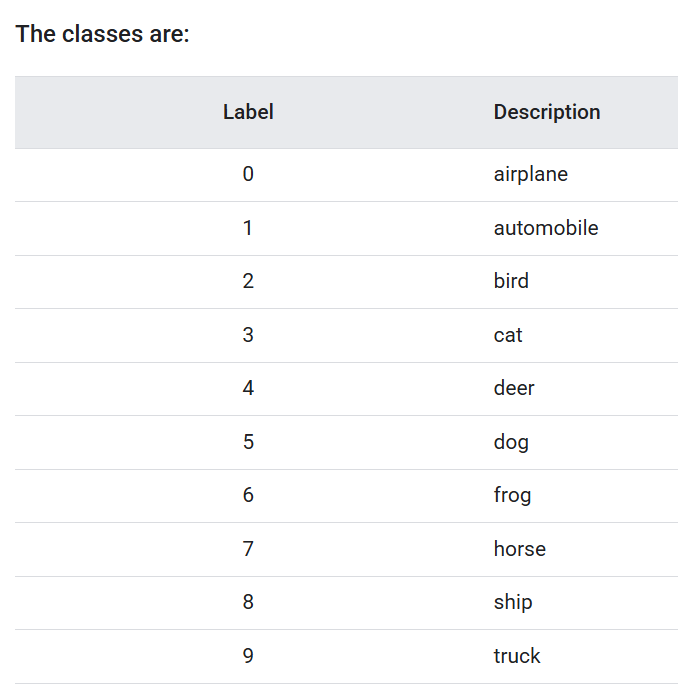

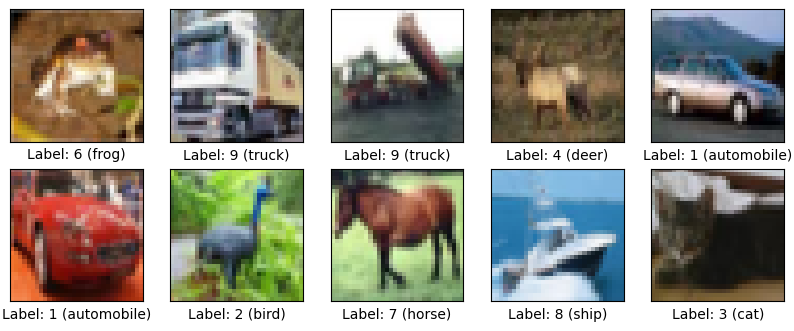

In [7]:
# STEP 3 - Sample images from the dataset
# Displaying the first 10 images from the CIFAR-10 dataset

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(f"Label: {y_train[i][0]} ({class_names[y_train[i][0]]})")
plt.show()

In [8]:
# STEP 4 - Creating the CNN model

model = Sequential()

# 1st Convolutional Layer
model.add(Conv2D(32, (3,3), activation = 'relu',  input_shape = (32, 32, 3)))
model.add(MaxPooling2D((2,2)))

# 2nd Convolutional Layer
model.add(Conv2D(64, (3,3), activation= 'relu'))
model.add(MaxPooling2D((2,2)))

# 3rd Convolutional Layer
model.add(Conv2D(64, (3,3), activation= 'relu'))
model.add(MaxPooling2D((2,2)))

# Fully Connected Layer
model.add(Flatten())
model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))


In [9]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 2, 2, 64)          0

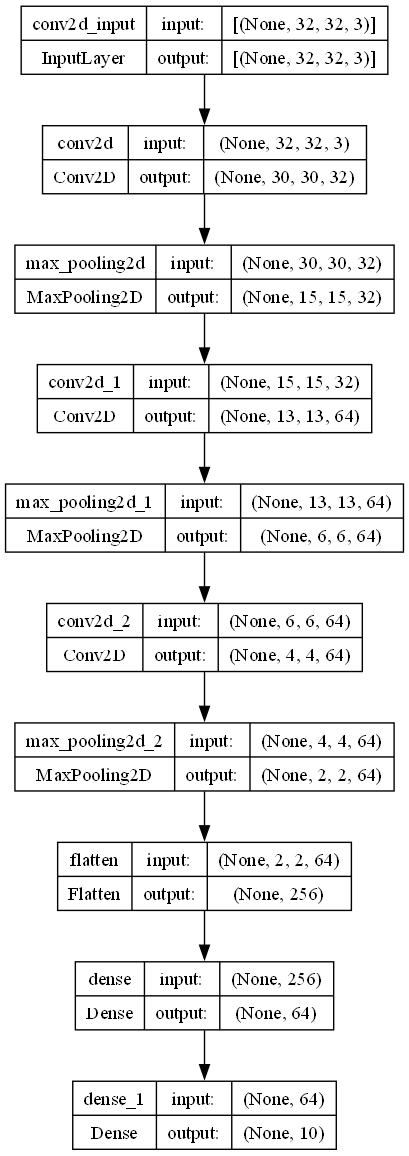

In [13]:
from tensorflow.keras.utils import plot_model

plot_model(model, 
           to_file='model.png', 
           show_shapes=True, 
           show_layer_names=True,
           rankdir='TB',  # Changes layout from vertical (TB) to horizontal (LR)
           dpi=100        # Increases resolution (dots per inch)
)

In [14]:
# STEP 5 : Compiling the model
model.compile(optimizer = 'adam', 
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics = ['accuracy']
)

In [15]:
# Step 6: Train the Model: On CPU it took 10 mintes
history = model.fit(X_train, y_train,
                    epochs=10,
                    verbose = 1,
                    validation_data=(X_test, y_test)
)

Epoch 1/10


1563/1563 [==============================] - 24s 14ms/step - loss: 1.6035 - accuracy: 0.4088 - val_loss: 1.3309 - val_accuracy: 0.5117
Epoch 2/10
1563/1563 [==============================] - 22s 14ms/step - loss: 1.2581 - accuracy: 0.5502 - val_loss: 1.1691 - val_accuracy: 0.5876
Epoch 3/10
1563/1563 [==============================] - 21s 13ms/step - loss: 1.1104 - accuracy: 0.6083 - val_loss: 1.0803 - val_accuracy: 0.6235
Epoch 4/10
1563/1563 [==============================] - 23s 15ms/step - loss: 1.0176 - accuracy: 0.6431 - val_loss: 1.0167 - val_accuracy: 0.6366
Epoch 5/10
1563/1563 [==============================] - 22s 14ms/step - loss: 0.9443 - accuracy: 0.6678 - val_loss: 0.9835 - val_accuracy: 0.6492
Epoch 6/10
1563/1563 [==============================] - 22s 14ms/step - loss: 0.8925 - accuracy: 0.6863 - val_loss: 0.9531 - val_accuracy: 0.6634
Epoch 7/10
1563/1563 [==============================] - 24s 15ms/step - loss: 0.8450 - accuracy: 0.7025 - val_loss: 0.9351

In [16]:
# Lets save the model so that we do can re-use this
model.save("cnn_model.keras")

# To load model:
# from tensorflow.keras.models import load_model
# model = load_model("cnn_model.h5")   # or "cnn_model.keras"

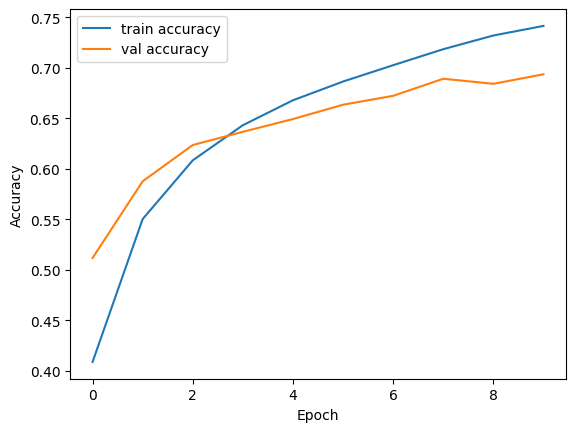

In [17]:
# Plot Training Accuracy and Loss
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [18]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose = 1)
print('Test Accuracy is',test_acc)

313/313 [==============================] - 2s 5ms/step - loss: 0.8900 - accuracy: 0.6935
Test Accuracy is 0.6934999823570251


In [19]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose = 1)
print('Train Accuracy is',train_acc)

1563/1563 [==============================] - 7s 5ms/step - loss: 0.6619 - accuracy: 0.7673
Test Accuracy is 0.767300009727478


In [ ]:
# Lets test on few images

In [20]:
!pip install opencv-python --no-deps

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


In [21]:
import cv2 as cv

(543, 965, 3)


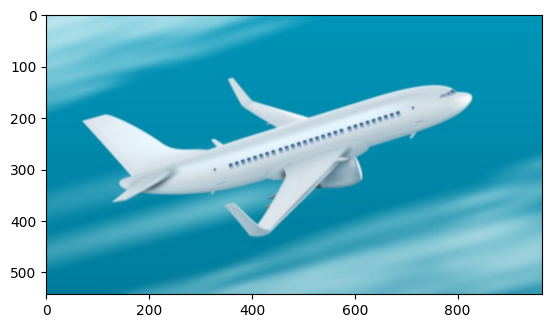

In [22]:
# Reading Image from directory
test_img = cv.imread("plane.jpg")
plt.imshow(test_img)
print(test_img.shape)

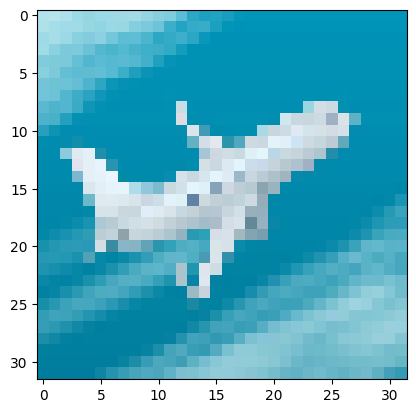

In [23]:
# Resize image
test_img = cv.resize(test_img,(32,32))
plt.imshow(test_img)
test_input = test_img.reshape(1,32,32,3)

In [28]:
# Prediction

prediction = model.predict(test_input)
print("Predicted probabality:", prediction)

pred_index = np.argmax(prediction)
print("index:", pred_index)

1/1 [==============================] - 0s 168ms/step
Predicted probabality: [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
index: 0


In [29]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
predicted_label = class_names[pred_index]
print(predicted_label)


airplane


(636, 637, 3)


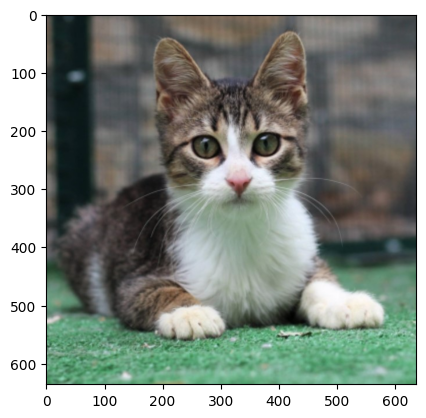

In [30]:
# Reading Image from directory
test_img = cv.imread("cat.jpg")
plt.imshow(test_img)
print(test_img.shape)

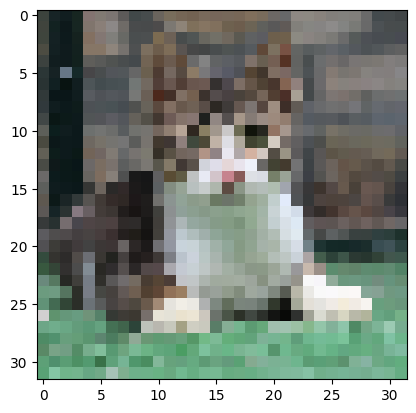

In [31]:
# Resize image
test_img = cv.resize(test_img,(32,32))
plt.imshow(test_img)
test_input = test_img.reshape(1,32,32,3)

In [32]:
# Prediction

prediction = model.predict(test_input)
print("Predicted probabality:", prediction)

pred_index = np.argmax(prediction)
print("index:", pred_index)

1/1 [==============================] - 0s 49ms/step
Predicted probabality: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
index: 3


In [33]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
predicted_label = class_names[pred_index]
print(predicted_label)


cat


(639, 641, 3)


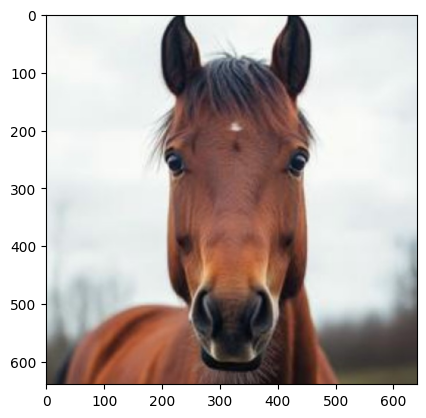

In [40]:
# Reading Image from directory
test_img = cv.imread("horse.jpg")
plt.imshow(test_img)
print(test_img.shape)

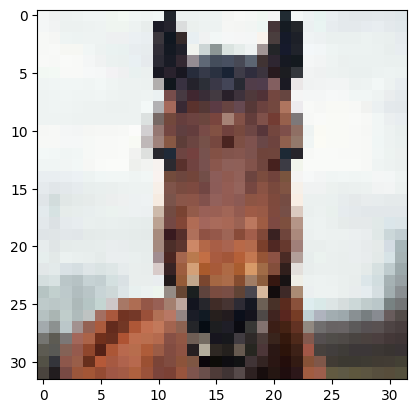

In [41]:
# Resize image
test_img = cv.resize(test_img,(32,32))
plt.imshow(test_img)
test_input = test_img.reshape(1,32,32,3)

In [42]:
# Prediction

prediction = model.predict(test_input)
print("Predicted probabality:", prediction)

pred_index = np.argmax(prediction)
print("index:", pred_index)

1/1 [==============================] - 0s 50ms/step
Predicted probabality: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
index: 9


In [43]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
predicted_label = class_names[pred_index]
print(predicted_label)


truck


## This one is wrong